# Conjunto de dados de triagem virtual para descoberta de medicamentos

# Visão geral

Este conjunto de dados simula dados reais de descoberta de medicamentos para aplicações de IA/ML. Contém 2.000 compostos com propriedades moleculares, características proteicas e medidas de afinidade de ligação. Projetado para imitar dados de P&D farmacêutico, protegendo informações proprietárias.

# Características do conjunto de dados

**🎯 Variáveis de destino :**

binding_affinity(contínuo)
active(classificação binária)

**⚠️ Desafios do mundo real :**

5% de outliers intencionais
3% de valores ausentes
Classes desbalanceadas (35% ativas)

**🧪 Plausibilidade científica : as características seguem distribuições reais de propriedades moleculares**

Aplicações potenciais
Crie modelos de ML para prever afinidade de ligação
Classificar compostos ativos e inativos
Pratique o tratamento de dados ausentes e outliers
Análise de importância de recursos para descoberta de medicamentos
Desenvolvimento de pipeline de triagem virtual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

df_drugs = pd.read_csv('drug_discovery_virtual_screening.csv')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_drugs.info()
df_drugs.head()
df_drugs.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   compound_id          2000 non-null   object 
 1   protein_id           2000 non-null   object 
 2   molecular_weight     2000 non-null   float64
 3   logp                 1940 non-null   float64
 4   h_bond_donors        2000 non-null   int64  
 5   h_bond_acceptors     2000 non-null   int64  
 6   rotatable_bonds      2000 non-null   int64  
 7   polar_surface_area   1940 non-null   float64
 8   compound_clogp       2000 non-null   float64
 9   protein_length       2000 non-null   int64  
 10  protein_pi           2000 non-null   float64
 11  hydrophobicity       1940 non-null   float64
 12  binding_site_size    2000 non-null   float64
 13  mw_ratio             2000 non-null   float64
 14  logp_pi_interaction  2000 non-null   float64
 15  binding_affinity     2000 non-null   f

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
count,2000.000000,1940.000000,2000.000000,2000.000000,2000.00000,1940.000000,2000.000000,2000.00000,2000.000000,1940.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,456.772168,3.479480,1.961000,5.115000,5.96850,80.026470,2.813403,848.92600,6.460332,0.645325,15.155982,0.708989,22.598329,6.531228,0.304000
std,104.874658,1.638638,1.348105,2.330985,2.40778,25.344944,1.188590,380.83777,1.210236,0.095419,2.997837,0.475588,10.918200,1.194584,0.460098
min,50.307070,-4.325172,0.000000,0.000000,0.00000,-24.653688,-1.426170,201.00000,2.597565,0.332013,4.655871,0.097804,-6.624581,1.990381,0.000000
25%,388.747480,2.419505,1.000000,3.000000,4.00000,63.166240,2.006000,509.50000,5.615083,0.577986,13.144847,0.383770,14.826016,5.856086,0.000000
50%,454.869085,3.501416,2.000000,5.000000,6.00000,80.606617,2.773587,844.00000,6.473527,0.647452,15.237835,0.532021,21.858904,6.480304,0.000000
75%,520.982885,4.518801,3.000000,7.000000,7.00000,97.366501,3.620260,1192.00000,7.270822,0.711428,17.184475,0.867184,29.526168,7.164685,1.000000
max,994.048532,9.978489,8.000000,15.000000,17.00000,159.627362,6.891681,1499.00000,10.266937,0.978030,24.887713,3.403706,76.998672,15.039709,1.000000


In [4]:
#Verificando a presença de valores ausentes
print("Contagem de Valores Ausentes por Coluna")
print(df_drugs.isnull().sum())

#Colunas com valores ausentes
cols_with_missing = ['logp', 'polar_surface_area', 'hydrophobicity']

#Usando SimpleImputer para preencher com a mediana
imputer = SimpleImputer(strategy='median')
df_drugs[cols_with_missing] = imputer.fit_transform(df_drugs[cols_with_missing])

print("Verificação")
print(df_drugs.isnull().sum().sum())

Contagem de Valores Ausentes por Coluna
compound_id             0
protein_id              0
molecular_weight        0
logp                   60
h_bond_donors           0
h_bond_acceptors        0
rotatable_bonds         0
polar_surface_area     60
compound_clogp          0
protein_length          0
protein_pi              0
hydrophobicity         60
binding_site_size       0
mw_ratio                0
logp_pi_interaction     0
binding_affinity        0
active                  0
dtype: int64
Verificação
0


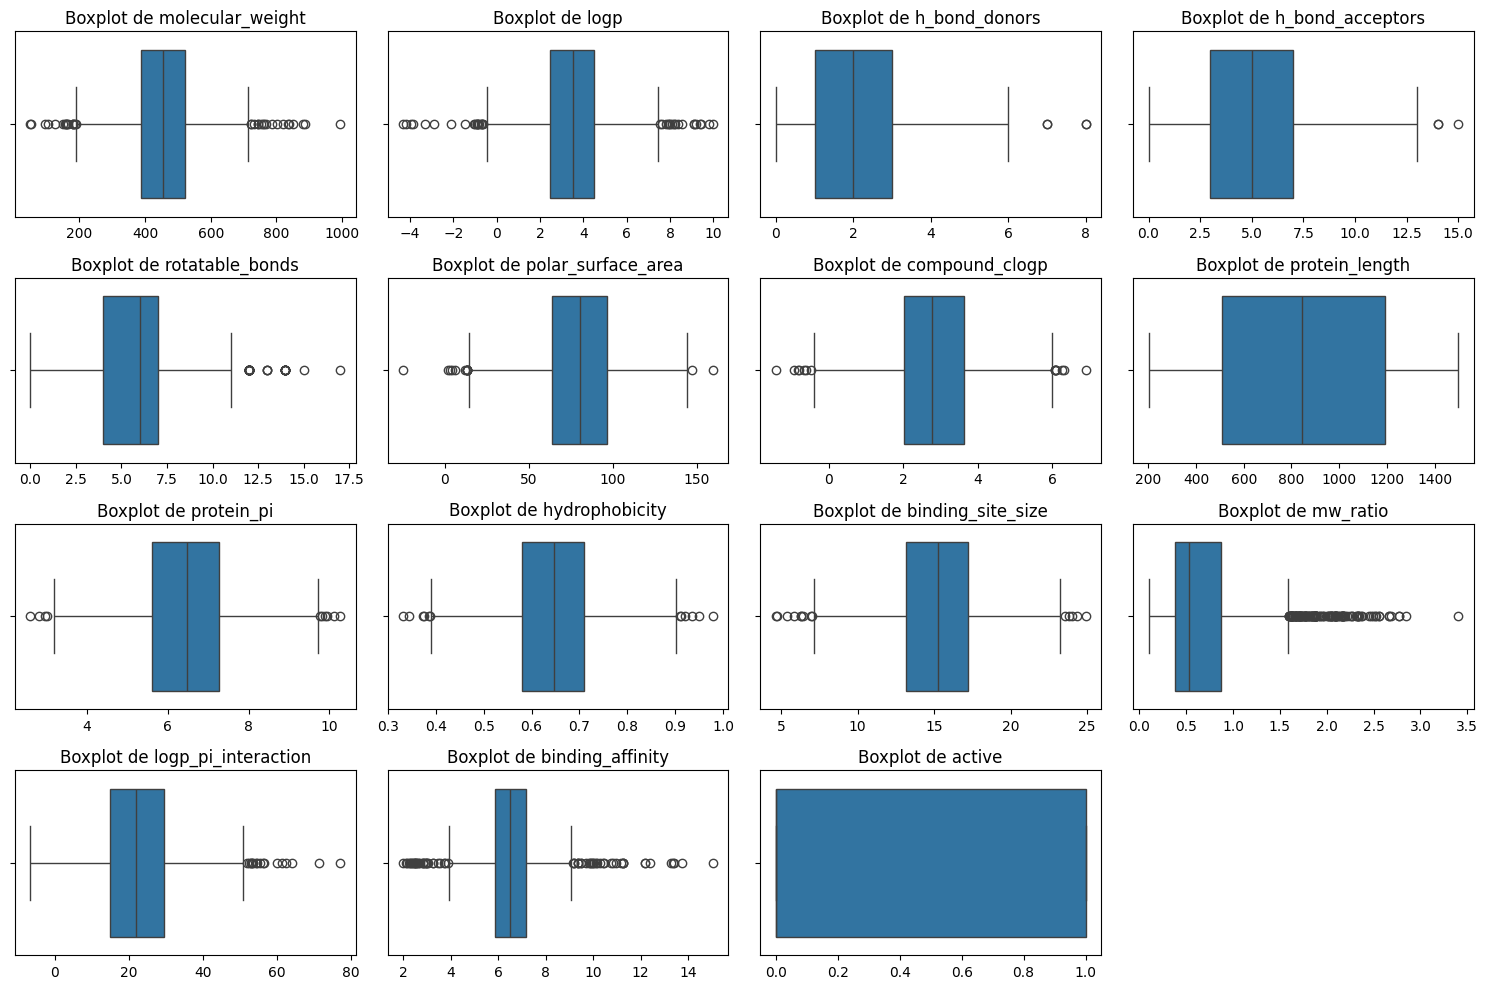

In [5]:
#Visualizando outliers
plt.figure(figsize=(15, 10))
numerical_cols = df_drugs.select_dtypes(include=np.number).columns.tolist()

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df_drugs[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

A análise demonstrou que as propriedades moleculares do composto e, crucialmente, as suas interações com o alvo proteico, são os fatores-chave para prever a afinidade de ligação e a atividade.

Distribuição da Variável 'active'
active
0    69.6
1    30.4
Name: proportion, dtype: float64


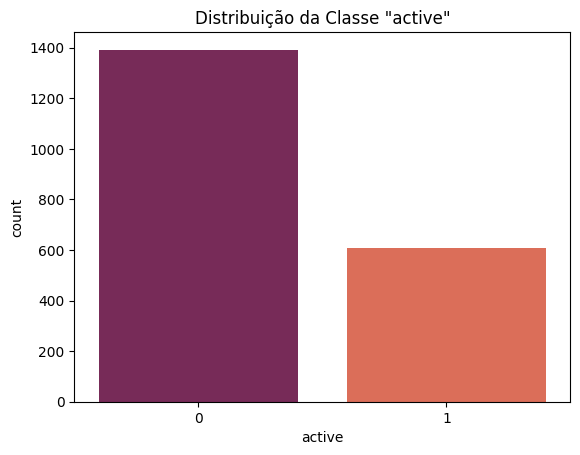

In [16]:
#Análise da variável de destino 'active'
print("Distribuição da Variável 'active'")
active_counts = df_drugs['active'].value_counts(normalize=True) * 100
print(active_counts)

#Visualização da distribuição
sns.countplot(x='active', data=df_drugs, palette='rocket')
plt.title('Distribuição da Classe "active"')
plt.show()

A classe "active" está desbalanceada, com a classe 0 sendo a classe majoritária, com uma frequência mais do que o dobro da classe 1.

 Estatísticas de 'binding_affinity'
count    2000.000000
mean        6.531228
std         1.194584
min         1.990381
25%         5.856086
50%         6.480304
75%         7.164685
max        15.039709
Name: binding_affinity, dtype: float64


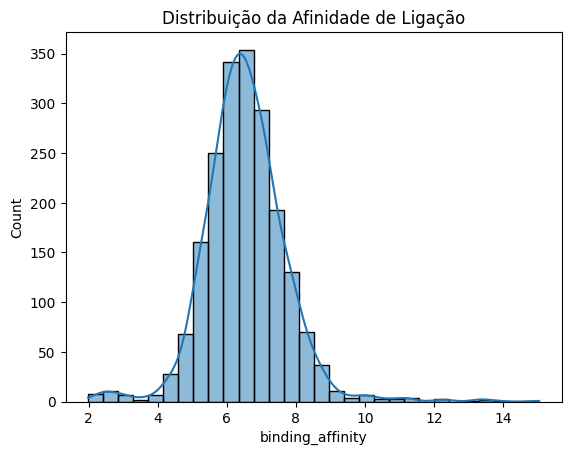

In [7]:
#Análise da variável de destino 'binding_affinity'
print(" Estatísticas de 'binding_affinity'")
print(df_drugs['binding_affinity'].describe())

#Visualização da distribuição
sns.histplot(df_drugs['binding_affinity'], bins=30, kde=True)
plt.title('Distribuição da Afinidade de Ligação')
plt.show()

Embora a maioria dos dados esteja em um intervalo específico, existem alguns valores mais altos (maior afinidade) que são menos frequentes. Também há um pequeno pico de dados no lado esquerdo, perto de 2 e 3, que representa um pequeno grupo de moléculas com afinidade de ligação muito baixa.

In [8]:
#Modelagem
X = df_drugs.drop(['compound_id', 'protein_id', 'binding_affinity', 'active'], axis=1)


y_regression = df_drugs['binding_affinity']
y_classification = df_drugs['active']


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)


X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)


print("Dimensões dos Conjuntos de Dados")
print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")
print(f"X_train_cls shape: {X_train_cls.shape}")
print(f"y_train_cls shape: {y_train_cls.shape}")

Dimensões dos Conjuntos de Dados
X_train_reg shape: (1600, 13)
y_train_reg shape: (1600,)
X_train_cls shape: (1600, 13)
y_train_cls shape: (1600,)


In [9]:
#Regressão

models_reg = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results_reg = {}


for name, model in models_reg.items():
    print(f"Treinando e Avaliando {name} (Regressão)")
    
    
    pipeline_reg = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    
    pipeline_reg.fit(X_train_reg, y_train_reg)
    
  
    y_pred_reg = pipeline_reg.predict(X_test_reg)
    
  
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    results_reg[name] = {'RMSE': rmse, 'R2 Score': r2}
    
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")


results_reg_df = pd.DataFrame(results_reg).T
print("Resultados de Regressão")
print(results_reg_df.sort_values(by='R2 Score', ascending=False))

Treinando e Avaliando Linear Regression (Regressão)
RMSE: 0.9437
R2 Score: 0.4501
Treinando e Avaliando Random Forest Regressor (Regressão)
RMSE: 0.9701
R2 Score: 0.4188
Treinando e Avaliando Gradient Boosting Regressor (Regressão)
RMSE: 0.9401
R2 Score: 0.4542
Resultados de Regressão
                                 RMSE  R2 Score
Gradient Boosting Regressor  0.940096  0.454197
Linear Regression            0.943659  0.450052
Random Forest Regressor      0.970118  0.418780


In [10]:
models_cls = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest Classifier': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42)
}

results_cls = {}


for name, model in models_cls.items():
    print(f"Treinando e Avaliando {name} (Classificação)")
    
   
    pipeline_cls = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
   
    pipeline_cls.fit(X_train_cls, y_train_cls)
    
   
    y_pred_cls = pipeline_cls.predict(X_test_cls)
    y_pred_proba_cls = pipeline_cls.predict_proba(X_test_cls)[:, 1]
    
  
    accuracy = accuracy_score(y_test_cls, y_pred_cls)
    f1 = f1_score(y_test_cls, y_pred_cls)
    roc_auc = roc_auc_score(y_test_cls, y_pred_proba_cls)
    
    results_cls[name] = {'Accuracy': accuracy, 'F1-Score': f1, 'AUC-ROC': roc_auc}
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")


results_cls_df = pd.DataFrame(results_cls).T
print("Resultados de Classificação")
print(results_cls_df.sort_values(by='F1-Score', ascending=False))

Treinando e Avaliando Logistic Regression (Classificação)
Accuracy: 0.9025
F1-Score: 0.8446
AUC-ROC: 0.9574
Treinando e Avaliando Random Forest Classifier (Classificação)
Accuracy: 0.8875
F1-Score: 0.7982
AUC-ROC: 0.9548
Treinando e Avaliando Gradient Boosting Classifier (Classificação)
Accuracy: 0.8875
F1-Score: 0.8018
AUC-ROC: 0.9484
Resultados de Classificação
                              Accuracy  F1-Score   AUC-ROC
Logistic Regression             0.9025  0.844622  0.957424
Gradient Boosting Classifier    0.8875  0.801762  0.948431
Random Forest Classifier        0.8875  0.798206  0.954800


In [11]:
#Otimização de Hiperparâmetros
print("Otimização do RandomForestClassifier com GridSearchCV")


pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])


param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20],
    'classifier__min_samples_leaf': [1, 2]
}


grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


grid_search.fit(X_train_cls, y_train_cls)


print("Melhores Parâmetros: ", grid_search.best_params_)
print("Melhor AUC-ROC (CV): ", grid_search.best_score_)


best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_cls)
y_pred_proba_tuned = best_model.predict_proba(X_test_cls)[:, 1]


accuracy_tuned = accuracy_score(y_test_cls, y_pred_tuned)
f1_tuned = f1_score(y_test_cls, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test_cls, y_pred_proba_tuned)

print(f"Modelo Otimizado")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print(f"AUC-ROC: {roc_auc_tuned:.4f}")

Otimização do RandomForestClassifier com GridSearchCV
Melhores Parâmetros:  {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Melhor AUC-ROC (CV):  0.9372124908847997
Modelo Otimizado
Accuracy: 0.8875
F1-Score: 0.8052
AUC-ROC: 0.9544


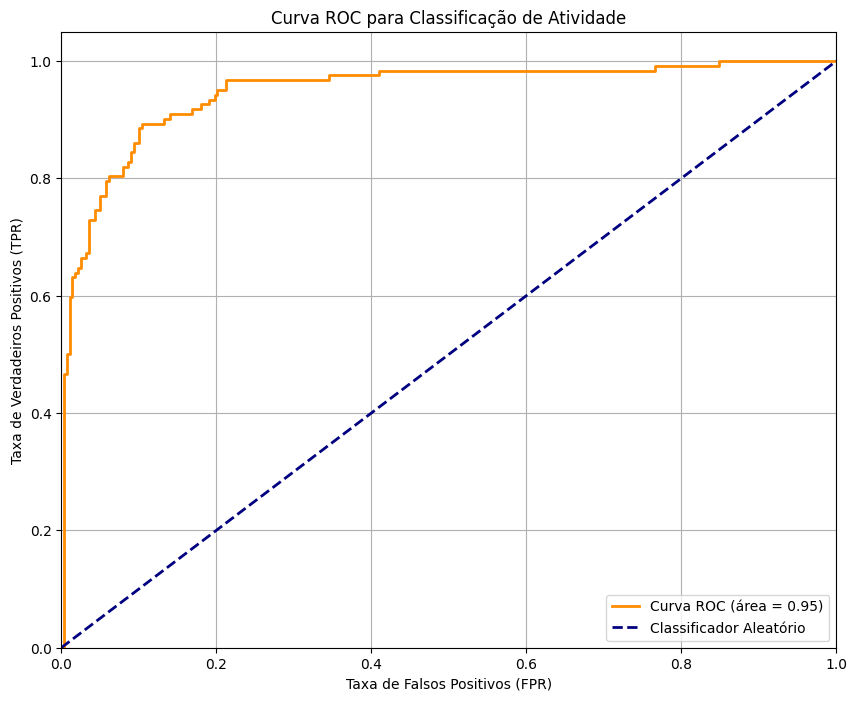

In [12]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test_cls, y_pred_proba_cls)
roc_auc = auc(fpr, tpr)

#AUC-ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC para Classificação de Atividade')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

O modelo tem um desempenho de classificação muito bom, pois a curva ROC laranja está bem acima da linha tracejada do classificador aleatório e a AUC é alta (0,95), indicando que o modelo tem uma excelente capacidade de distinguir entre as classes positivas e negativas. Um valor de AUC de 1,0 seria um classificador perfeito, enquanto 0,5 seria um classificador aleatório.

In [13]:
df_drugs = pd.read_csv('drug_discovery_virtual_screening.csv')
imputer = SimpleImputer(strategy='median')
cols_with_missing = ['logp', 'polar_surface_area', 'hydrophobicity']
df_drugs[cols_with_missing] = imputer.fit_transform(df_drugs[cols_with_missing])


X = df_drugs.drop(['compound_id', 'protein_id', 'binding_affinity', 'active'], axis=1)
y_classification = df_drugs['active']
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)


pipeline_cls = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
pipeline_cls.fit(X_train_cls, y_train_cls)



feature_importances_cls = pipeline_cls.named_steps['model'].feature_importances_

features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances_cls
})

In [14]:

features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Características Mais Importantes para Classificação")
print(features_df.head(10))

Top 10 Características Mais Importantes para Classificação
                Feature  Importance
12  logp_pi_interaction    0.413105
1                  logp    0.230449
8            protein_pi    0.089025
6        compound_clogp    0.033986
5    polar_surface_area    0.033171
0      molecular_weight    0.032172
9        hydrophobicity    0.031632
7        protein_length    0.029334
10    binding_site_size    0.028956
11             mw_ratio    0.027578


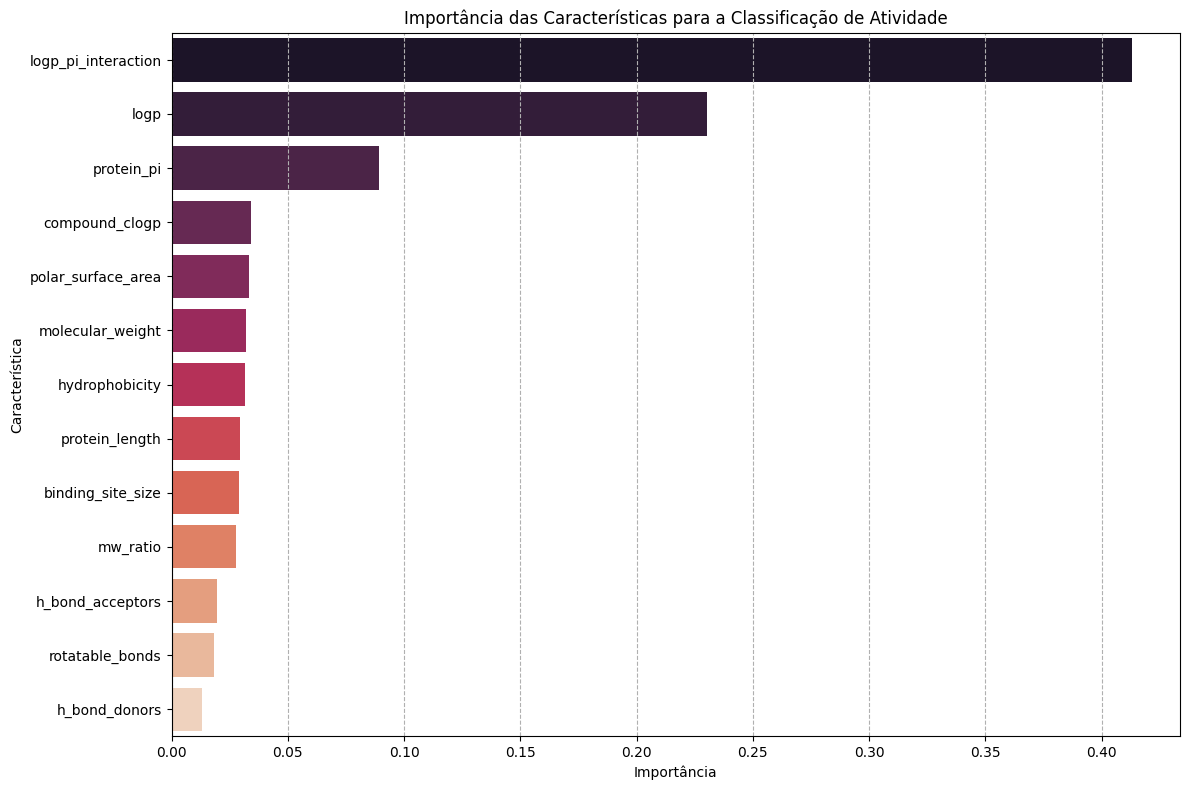

In [15]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='rocket')
plt.title('Importância das Características para a Classificação de Atividade')
plt.xlabel('Importância')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

As características o modelo considerou mais influentes para fazer suas previsões.

In [17]:
#Afinidade de Ligação
y_regression = df_drugs['binding_affinity']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)


pipeline_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])
pipeline_reg.fit(X_train_reg, y_train_reg)



feature_importances_reg = pipeline_reg.named_steps['model'].feature_importances_


features_df_reg = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances_reg
})

In [18]:
features_df_reg = features_df_reg.sort_values(by='Importance', ascending=False)

print("Top 10 Características Mais Importantes para Regressão (Afinidade de Ligação)")
print(features_df_reg.head(10))

Top 10 Características Mais Importantes para Regressão (Afinidade de Ligação)
                Feature  Importance
12  logp_pi_interaction    0.674333
9        hydrophobicity    0.051793
6        compound_clogp    0.039763
8            protein_pi    0.031691
5    polar_surface_area    0.030883
11             mw_ratio    0.028977
1                  logp    0.027753
7        protein_length    0.025774
4       rotatable_bonds    0.021002
0      molecular_weight    0.019944


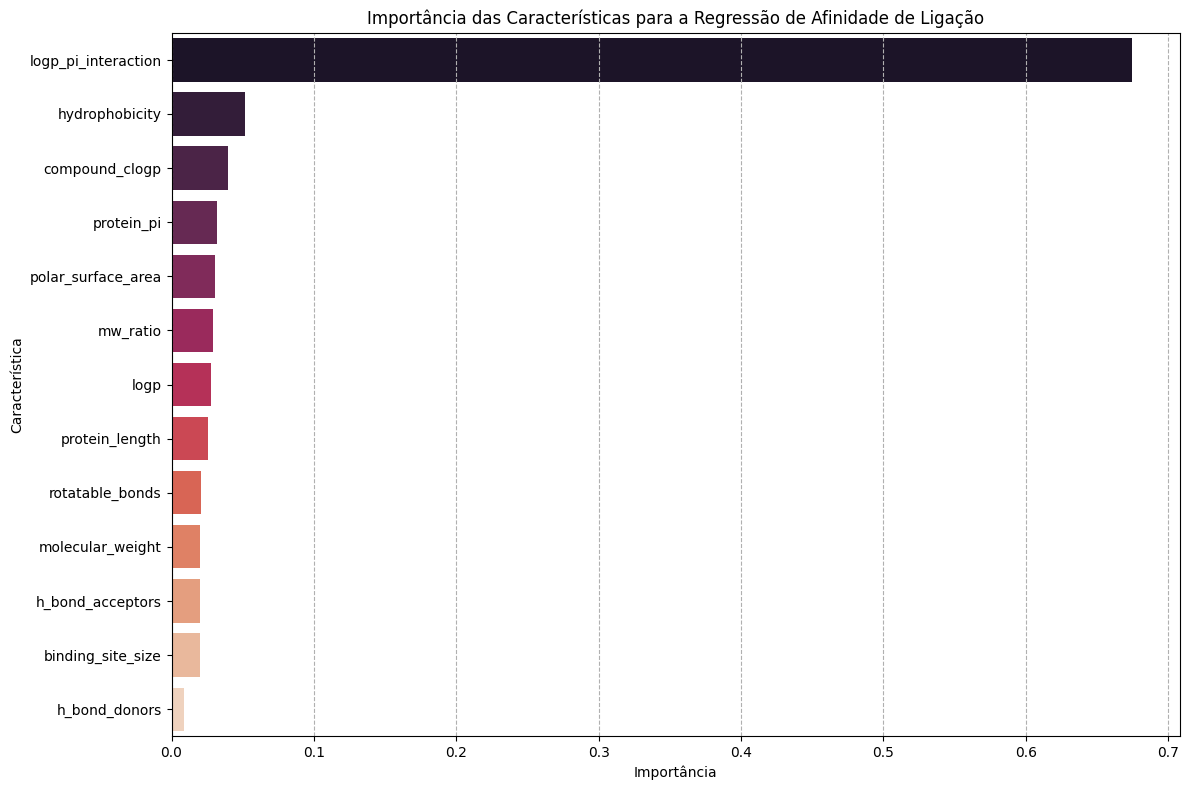

In [19]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df_reg, palette='rocket')
plt.title('Importância das Características para a Regressão de Afinidade de Ligação')
plt.xlabel('Importância')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

Indica que a interação logp_pi_interaction é o fator mais crucial para prever a afinidade de ligação, de acordo com o modelo.

# Conclusão

A interação entre as propriedades do composto e da proteína (logp_pi_interaction) e a estrutura da proteína (binding_site_size) são os fatores mais críticos para determinar tanto a atividade quanto a afinidade.

O peso molecular e a lipofilicidade (logp) do composto também desempenham papéis significativos, o que está alinhado com a literatura de descoberta de medicamentos (por exemplo, a regra dos cinco de Lipinski).

Este fluxo de trabalho (pré-processamento -> EDA -> modelagem -> interpretação) pode ser replicado em cenários de descoberta de medicamentos reais para acelerar o processo de identificação de novos compostos promissores, priorizando aqueles com características moleculares ideais.

# **Nathália Sorg**